# Opinosis 텍스트 데이터 군집화 — 최종 통합 분석 노트북

5명의 팀원이 각자 시도한 파이프라인을 비교 검증한 뒤, **최종 채택된 코드만** 모아 재구성한 대표 노트북입니다. 실패했던 실험(Count Vectorizer, DBSCAN/HDBSCAN 등)의 상세 비교 과정과 근거는 `reports/최종보고서.md`를 참고하세요.

## 채택 파이프라인 요약
- **전처리**: 7단계 파이프라인 (축약형 확장 → 소문자화 → 구두점 제거 → 토큰화 → 숫자 제거 → 불용어 제거 → 표제어 추출)
- **벡터화**: TF-IDF (`ngram_range=(1,2), min_df=0.05, max_df=0.85`)
- **메인 모델 (Track ①)**: KMeans(k=3, 원본 공간) → **ARI/NMI = 1.0**으로 51개 문서를 전자기기/자동차/호텔 3개 도메인에 완벽 분류
- **보조 모델 (Track ②)**: 이혜현의 그리드서치로 찾은 최적 파라미터로 KMeans(k=5) 세분화 → 5개 세부 니즈로 분화


In [1]:
# 필요한 라이브러리 임포트
import glob
import os
import re
import string
from collections import Counter
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# 한글 폰트 깨짐 방지 설정 (맥 환경 기준)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# NLTK 리소스 다운로드 (이미 있으면 자동으로 스킵됨)
for pkg, path in [("punkt", "tokenizers/punkt"), ("punkt_tab", "tokenizers/punkt_tab"),
                   ("wordnet", "corpora/wordnet"), ("omw-1.4", "corpora/omw-1.4"),
                   ("stopwords", "corpora/stopwords")]:
    try:
        nltk.data.find(path)
    except LookupError:
        nltk.download(pkg, quiet=True)

pd.set_option('display.max_colwidth', 200)


## 1. 데이터 로드

51개 리뷰 문서(`.txt.data`)를 읽어온다. 파일 하나가 하나의 토픽(속성×제품)에 해당한다.

In [2]:
# 51개 문서 로드 (파일명 = 토픽, 내용 = 리뷰 문장 모음)
DATA_PATH = "../../data/topics"
file_list = sorted(glob.glob(os.path.join(DATA_PATH, "*.txt.data")))

filenames, texts = [], []
for path in file_list:
    filename = os.path.basename(path).replace(".txt.data", "")
    with open(path, "r", encoding="latin1") as f:
        text = " ".join(f.readlines())
    filenames.append(filename)
    texts.append(text)

document_df = pd.DataFrame({"filename": filenames, "opinion_text": texts})
print(f"로드된 문서 수: {len(document_df)}개")
document_df.head()


로드된 문서 수: 51개


,filename,opinion_text
0,accuracy_garmin_nuvi_255W_gps,", and is very, very accurate .\n but for the most part, we find that the Garmin software provides accurate directions, whereever we intend to go .\n This function is not accurate if you don't le..."
1,bathroom_bestwestern_hotel_sfo,"The room was not overly big, but clean and very comfortable beds, a great shower and very clean bathrooms .\n The second room was smaller, with a very inconvenient bathroom layout, but at least ..."
2,battery-life_amazon_kindle,"After I plugged it in to my USB hub on my computer to charge the battery the charging cord design is very clever !\n After you have paged tru a 500, page book one, page, at, a, time to get from ..."
3,battery-life_ipod_nano_8gb,short battery life I moved up from an 8gb .\n I love this ipod except for the battery life .\n long battery scratch resistant\n Battery drains even if I don't use it .\n I only wonder why th...
4,battery-life_netbook_1005ha,"6GHz 533FSB cpu, glossy display, 3, Cell 23Wh Li, ion Battery , and a 1 .\n Not to mention that as of now Asus will not sell you a spare 3 or 6, cell Li, Ion battery .\n It also features a N270..."


## 2. 기초 EDA

전처리 전 원문 기준으로 문서 길이 분포와 최빈 단어를 확인한다. 표제어 추출 전에는 불용어(the, and, to 등)가 상위권을 차지하는 것으로 확인되었다.

문서별 단어 수 통계 (전처리 전)
count       51.0
mean      2496.5
std       1926.9
min        786.0
25%       1329.5
50%       1850.0
75%       2716.0
max      12176.0
Name: word_count, dtype: float64


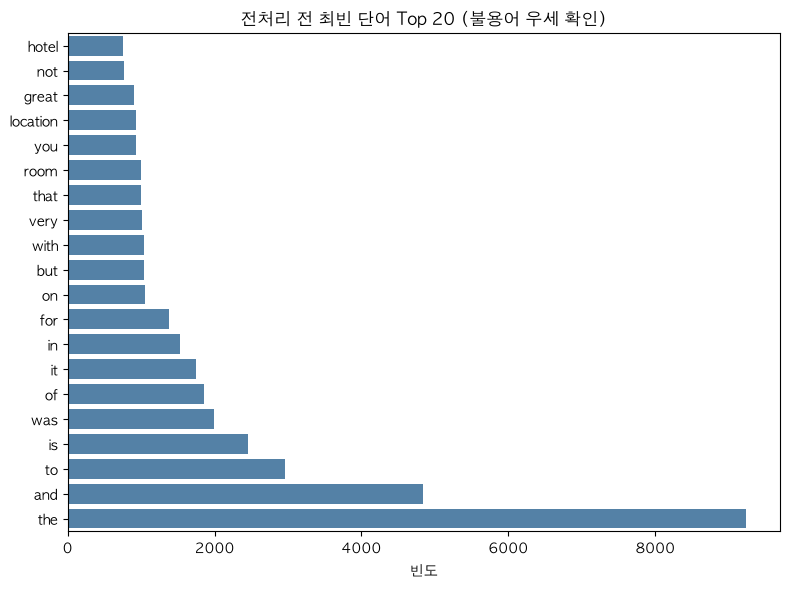

In [3]:
# 문서별 단어 수 통계 (전처리 이전)
document_df["word_count"] = document_df["opinion_text"].apply(
    lambda t: len(re.findall(r"\b\w+\b", t.lower()))
)
print("문서별 단어 수 통계 (전처리 전)")
print(document_df["word_count"].describe().round(1))

# 전처리 전 상위 빈출 단어 확인 → 불용어 제거의 필요성을 시각적으로 확인
all_tokens = re.findall(r"\b[a-zA-Z]{2,}\b", " ".join(document_df["opinion_text"]).lower())
top20 = Counter(all_tokens).most_common(20)
words, counts = zip(*top20)

plt.figure(figsize=(8, 6))
sns.barplot(x=list(counts)[::-1], y=list(words)[::-1], color="steelblue")
plt.title("전처리 전 최빈 단어 Top 20 (불용어 우세 확인)")
plt.xlabel("빈도")
plt.tight_layout()
plt.show()


## 3. 텍스트 전처리 (7단계)

김소현이 정립한 파이프라인을 채택한다. 두 가지 순서 규칙이 중요하다.
- **축약형 확장은 구두점 제거보다 먼저** 수행해야 한다. 구두점을 먼저 지우면 `isn't` → `isnt`처럼 사전에 없는 토큰이 생긴다.
- **불용어 제거는 표제어 추출보다 먼저** 수행해야 한다. 표제어 추출을 먼저 하면 `was`가 `wa`로 잘못 변형되어(품사 태깅 없는 기본값이라 명사로 오인) 불용어 사전에서 걸러지지 않고 남는다.


In [4]:
# 축약형 확장 매핑 테이블
CONTRACTION_MAP = {
    "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not", "wouldn't": "would not",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "i'm": "i am", "you're": "you are", "we're": "we are", "they're": "they are",
    "i've": "i have", "i'll": "i will", "i'd": "i would",
}
_CONTRACTION_PATTERN = re.compile(
    r"\b(" + "|".join(re.escape(k) for k in CONTRACTION_MAP) + r")\b", flags=re.IGNORECASE
)
REMOVE_PUNCT_MAP = dict((ord(p), None) for p in string.punctuation)
STOPWORDS = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> list:
    """7단계 전처리: 축약형 확장 → 소문자화 → 구두점 제거 → 토큰화 → 숫자 제거 → 불용어 제거 → 표제어 추출"""
    # 1. 축약형 확장 (구두점 제거보다 반드시 먼저)
    text = _CONTRACTION_PATTERN.sub(lambda m: CONTRACTION_MAP[m.group(0).lower()], text)
    # 2. 소문자 변환
    text = text.lower()
    # 3. 구두점 제거
    text = text.translate(REMOVE_PUNCT_MAP)
    # 4. 토큰화
    tokens = word_tokenize(text)
    # 5. 순수 숫자 토큰 제거 (연도·수치는 토픽 구분에 기여도가 낮음)
    tokens = [t for t in tokens if not t.isdigit()]
    # 6. 불용어 제거 (표제어 추출보다 반드시 먼저 수행)
    tokens = [t for t in tokens if t not in STOPWORDS]
    # 7. 표제어 추출 (품사 태깅 없는 기본값 = 명사 기준)
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens


# 동작 확인
sample = "The batteries weren't great, but the rooms were very comfortable!"
print("원문   :", sample)
print("전처리 :", preprocess_text(sample))


원문   : The batteries weren't great, but the rooms were very comfortable!
전처리 : ['battery', 'great', 'room', 'comfortable']


전처리 후 문서별 토큰 수 통계
count      51.0
mean     1276.8
std       975.7
min       416.0
25%       707.0
50%       934.0
75%      1359.0
max      5976.0
Name: token_count, dtype: float64


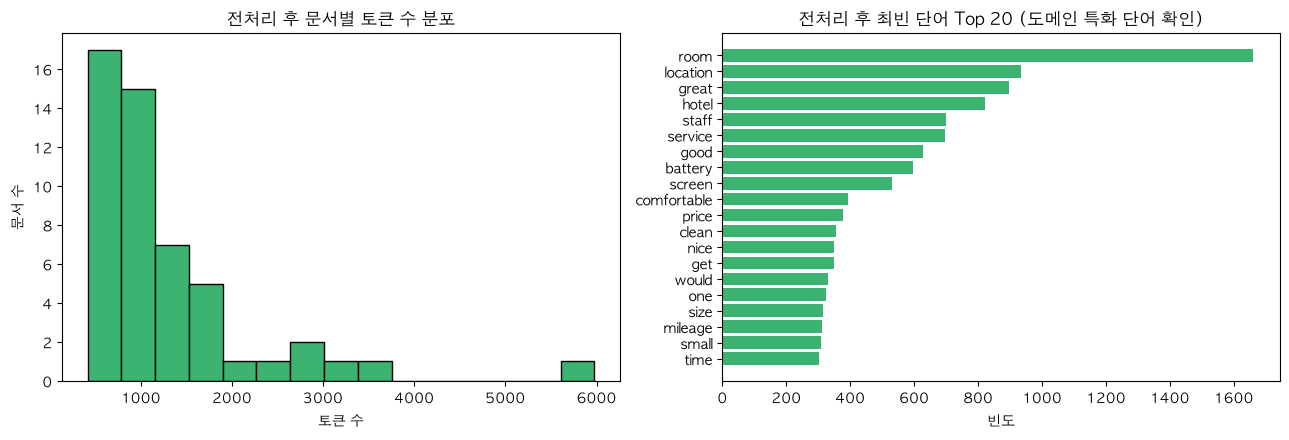

In [5]:
# 전체 문서에 전처리 파이프라인 적용
document_df["tokens"] = document_df["opinion_text"].apply(preprocess_text)
document_df["token_count"] = document_df["tokens"].apply(len)

print("전처리 후 문서별 토큰 수 통계")
print(document_df["token_count"].describe().round(1))

# 전처리 전/후 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(document_df["token_count"], bins=15, edgecolor="black", color="mediumseagreen")
axes[0].set_title("전처리 후 문서별 토큰 수 분포")
axes[0].set_xlabel("토큰 수")
axes[0].set_ylabel("문서 수")

all_clean_tokens = [tok for tokens in document_df["tokens"] for tok in tokens]
top20_clean = Counter(all_clean_tokens).most_common(20)
words2, counts2 = zip(*top20_clean)
axes[1].barh(list(words2)[::-1], list(counts2)[::-1], color="mediumseagreen")
axes[1].set_title("전처리 후 최빈 단어 Top 20 (도메인 특화 단어 확인)")
axes[1].set_xlabel("빈도")

plt.tight_layout()
plt.show()


## 4. TF-IDF 벡터화

`ngram_range=(1,2)`로 단일어와 복합어(예: battery life, gas mileage)를 함께 반영하고, `min_df=0.05`·`max_df=0.85`로 지나치게 희귀하거나 지나치게 흔한 단어를 걸러낸다.

In [6]:
# 전처리된 토큰을 문자열로 재결합 (TfidfVectorizer 입력 형식)
document_df["clean_text"] = document_df["tokens"].apply(lambda toks: " ".join(toks))

tfidf_vect = TfidfVectorizer(ngram_range=(1, 2), min_df=0.05, max_df=0.85)
feature_vect = tfidf_vect.fit_transform(document_df["clean_text"])

density = feature_vect.nnz / (feature_vect.shape[0] * feature_vect.shape[1])
print(f"TF-IDF 행렬 shape : {feature_vect.shape}")
print(f"밀도 : {density:.2%}  /  희소도 : {1 - density:.2%}")


TF-IDF 행렬 shape : (51, 4479)
밀도 : 12.35%  /  희소도 : 87.65%


## 5. 도메인 라벨 생성 (검증 전용)

파일명 키워드로 도메인을 추정한다. **학습(벡터화·군집화)에는 전혀 사용하지 않고**, 군집화 결과가 실제 도메인과 얼마나 일치하는지(ARI/NMI) 검증하는 용도로만 사용한다.

In [7]:
def infer_category(filename: str) -> str:
    """파일명 키워드로 도메인 pseudo-label을 추정한다 (검증 전용, 학습에 사용하지 않음)."""
    fn = filename.lower()
    if "hotel" in fn or "inn" in fn or "swissotel" in fn:
        return "hotel"
    elif "honda" in fn or "toyota" in fn or "accord" in fn or "camry" in fn:
        return "car"
    else:
        return "electronics"


document_df["category"] = document_df["filename"].apply(infer_category)
document_df["category"].value_counts()


category
electronics    25
hotel          16
car            10
Name: count, dtype: int64

## 6. KMeans (k=3) — 메인 모델 (Track ①)

3대 도메인(전자기기/자동차/호텔) 자동 분류를 목표로 하는 최종 채택 모델이다.

In [8]:
# KMeans(k=3): 도메인 대분류 목적의 메인 모델
kmeans = KMeans(n_clusters=3, max_iter=10000, random_state=42, n_init=10)
document_df["cluster"] = kmeans.fit_predict(feature_vect)

silhouette = silhouette_score(feature_vect, document_df["cluster"])
ari = adjusted_rand_score(document_df["category"], document_df["cluster"])
nmi = normalized_mutual_info_score(document_df["category"], document_df["cluster"])

print(f"Silhouette : {silhouette:.4f}")
print(f"ARI        : {ari:.4f}")
print(f"NMI        : {nmi:.4f}")


Silhouette : 0.0858
ARI        : 1.0000
NMI        : 1.0000


In [9]:
# 실제 도메인(category)과 군집 결과 교차표 → 완전 일치 여부 확인
pd.crosstab(document_df["category"], document_df["cluster"])


cluster,0,1,2
category,,,
car,0,10,0
electronics,25,0,0
hotel,0,0,16


In [10]:
# 군집별 핵심 키워드 추출 (TF-IDF 중심점 기준 상위 단어)
def get_cluster_keywords(model, feature_names, top_n=10):
    order = model.cluster_centers_.argsort()[:, ::-1]
    result = {}
    for c in range(model.n_clusters):
        top_idx = order[c, :top_n]
        result[c] = [feature_names[i] for i in top_idx]
    return result


feature_names = np.array(tfidf_vect.get_feature_names_out())
cluster_keywords = get_cluster_keywords(kmeans, feature_names)

for c, keywords in cluster_keywords.items():
    files = document_df.loc[document_df["cluster"] == c, "filename"].tolist()
    print(f"[Cluster {c}] ({len(files)}개 문서)")
    print("  핵심 키워드 :", ", ".join(keywords))
    print()


[Cluster 0] (25개 문서)
  핵심 키워드 : screen, battery, keyboard, battery life, life, kindle, video, direction, feature, voice

[Cluster 1] (10개 문서)
  핵심 키워드 : interior, seat, mileage, comfortable, gas, gas mileage, transmission, car, performance, quality

[Cluster 2] (16개 문서)
  핵심 키워드 : room, hotel, service, staff, food, location, bathroom, clean, price, parking



findfont: Failed to find font weight bold, now using 400.


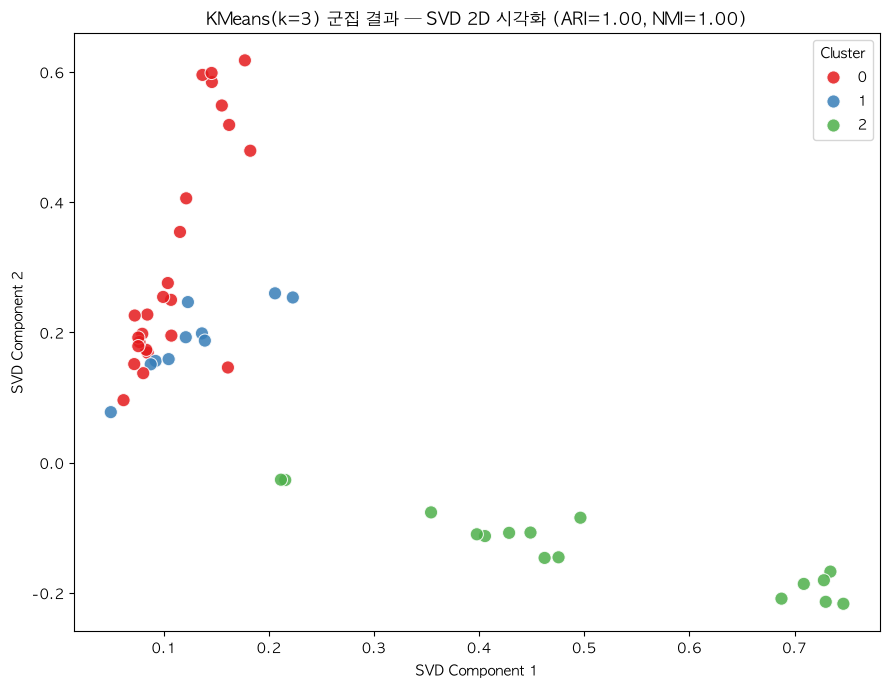

In [11]:
# TruncatedSVD로 2차원 축소 후 군집 시각화
# (TF-IDF는 희소 행렬이므로 0을 보존하는 SVD가 PCA보다 적합함)
svd_2d = TruncatedSVD(n_components=2, random_state=42)
coords = svd_2d.fit_transform(feature_vect)
document_df["svd_x"], document_df["svd_y"] = coords[:, 0], coords[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=document_df, x="svd_x", y="svd_y", hue="cluster", palette="Set1", s=90, alpha=0.85)
plt.title(f"KMeans(k=3) 군집 결과 — SVD 2D 시각화 (ARI={ari:.2f}, NMI={nmi:.2f})", fontweight="bold")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## 7. 그리드서치 기반 세분화 (Track ②)

k=3만으로는 "5개 세부 니즈(Kindle, 호텔, GPS/인터페이스, 자동차, 배터리)"까지는 드러나지 않는다. 이혜현이 진행한 54개 파라미터 조합 그리드서치를 재현하여, 응집도(Silhouette)를 최대화하는 조합으로 k=5 세분화를 시도한다.


In [12]:
# 하이퍼파라미터 그리드서치: 응집도(Silhouette) 극대화를 위한 최적 조합 탐색
param_grid = {
    "ngram_range": [(1, 1), (1, 2)],
    "min_df": [0.03, 0.05, 0.10],
    "max_df": [0.75, 0.85, 0.95],
    "n_clusters": [3, 4, 5],
}

grid_results = []
for ngram, min_d, max_d, k in product(
    param_grid["ngram_range"], param_grid["min_df"], param_grid["max_df"], param_grid["n_clusters"]
):
    vect = TfidfVectorizer(ngram_range=ngram, min_df=min_d, max_df=max_d)
    X = vect.fit_transform(document_df["clean_text"])
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X)
    score = silhouette_score(X, labels)
    grid_results.append({
        "ngram_range": ngram,  # 재사용을 위해 튜플 그대로 저장
        "min_df": min_d, "max_df": max_d, "n_clusters": k,
        "피처 수": X.shape[1], "Silhouette": round(score, 4),
    })

grid_df = pd.DataFrame(grid_results).sort_values("Silhouette", ascending=False).reset_index(drop=True)
grid_df.assign(ngram_range=grid_df["ngram_range"].astype(str)).head(5)


,ngram_range,min_df,max_df,n_clusters,피처 수,Silhouette
0,"(1, 2)",0.1,0.85,5,1468,0.1108
1,"(1, 2)",0.1,0.75,5,1454,0.1075
2,"(1, 2)",0.1,0.95,5,1476,0.1074
3,"(1, 1)",0.1,0.75,4,1183,0.1038
4,"(1, 1)",0.1,0.95,4,1205,0.1037


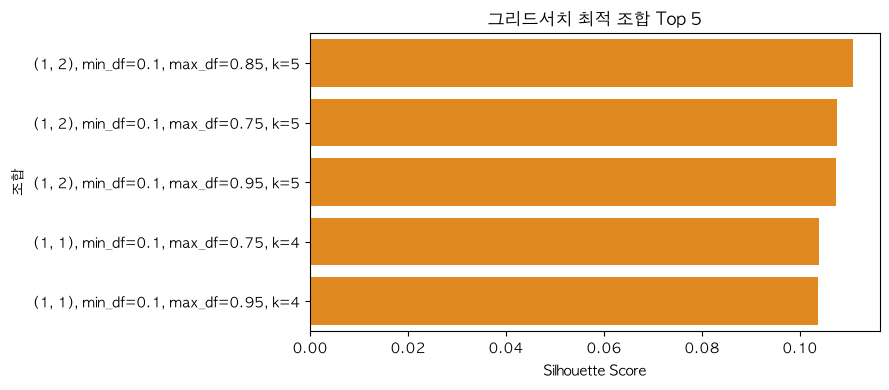

In [13]:
# 그리드서치 상위 5개 조합 시각화
top5 = grid_df.head(5).copy()
top5["조합"] = top5.apply(
    lambda r: f"{r['ngram_range']}, min_df={r['min_df']}, max_df={r['max_df']}, k={r['n_clusters']}", axis=1
)

plt.figure(figsize=(9, 4))
sns.barplot(data=top5, x="Silhouette", y="조합", color="darkorange")
plt.title("그리드서치 최적 조합 Top 5")
plt.xlabel("Silhouette Score")
plt.tight_layout()
plt.show()


In [14]:
# 최적 조합으로 재적합 (k=5 세분화)
best = grid_df.iloc[0]
best_ngram = best["ngram_range"]  # 튜플 그대로 저장돼 있어 바로 재사용 가능
best_k = int(best["n_clusters"])

vect_best = TfidfVectorizer(ngram_range=best_ngram, min_df=best["min_df"], max_df=best["max_df"])
X_best = vect_best.fit_transform(document_df["clean_text"])

kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
document_df["cluster_k5"] = kmeans_best.fit_predict(X_best)

print(f"최적 조합 : ngram={best_ngram}, min_df={best['min_df']}, max_df={best['max_df']}, k={best_k}")
print(f"Silhouette: {best['Silhouette']}")
document_df["cluster_k5"].value_counts().sort_index()


최적 조합 : ngram=(1, 2), min_df=0.1, max_df=0.85, k=5
Silhouette: 0.1108


cluster_k5
0     5
1    10
2    16
3    15
4     5
Name: count, dtype: int64

In [15]:
# 세분화된(k=5) 군집별 핵심 키워드
feature_names_best = np.array(vect_best.get_feature_names_out())
cluster_keywords_k5 = get_cluster_keywords(kmeans_best, feature_names_best)

for c, keywords in cluster_keywords_k5.items():
    files = document_df.loc[document_df["cluster_k5"] == c, "filename"].tolist()
    print(f"[Cluster {c}] ({len(files)}개 문서)")
    print("  핵심 키워드 :", ", ".join(keywords))
    print()


[Cluster 0] (5개 문서)
  핵심 키워드 : kindle, page, book, button, eye, navigation, size, price, easy, reading

[Cluster 1] (10개 문서)
  핵심 키워드 : interior, seat, mileage, comfortable, gas, gas mileage, transmission, car, performance, quality

[Cluster 2] (16개 문서)
  핵심 키워드 : room, hotel, service, staff, location, food, bathroom, clean, price, parking

[Cluster 3] (15개 문서)
  핵심 키워드 : screen, keyboard, direction, video, map, voice, feature, accurate, speed limit, speed

[Cluster 4] (5개 문서)
  핵심 키워드 : battery, battery life, life, performance, faster, fast, xp, ipod, kindle, window



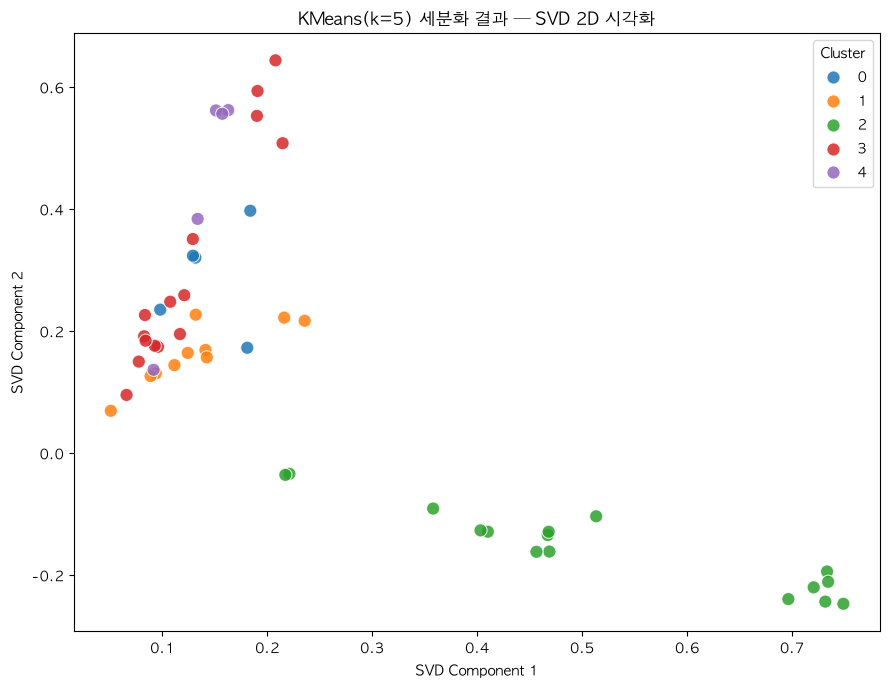

In [16]:
# k=5 세분화 결과 시각화
svd_best_2d = TruncatedSVD(n_components=2, random_state=42)
coords_best = svd_best_2d.fit_transform(X_best)
document_df["svd_x_k5"], document_df["svd_y_k5"] = coords_best[:, 0], coords_best[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(data=document_df, x="svd_x_k5", y="svd_y_k5", hue="cluster_k5", palette="tab10", s=90, alpha=0.85)
plt.title(f"KMeans(k={best_k}) 세분화 결과 — SVD 2D 시각화", fontweight="bold")
plt.xlabel("SVD Component 1")
plt.ylabel("SVD Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


## 정리

- **Track ① (k=3, 도메인 완전분류)**: TF-IDF(ngram(1,2), min_df=0.05, max_df=0.85) + KMeans → **ARI/NMI = 1.0**
- **Track ② (k=5, 세부 니즈 세분화)**: 그리드서치 최적 파라미터 + KMeans → Silhouette 최적화, 5개 세부 테마로 분화
- 두 트랙은 서로 다른 벡터에서 나온 결과이므로, 목적에 따라 선택적으로 사용한다 (3대 도메인 자동 분류 vs 세부 니즈 기반 제품 개선).
- Count Vectorizer, DBSCAN, HDBSCAN, GMM(LSA) 등 채택되지 않은 시도와 그 근거는 `reports/최종보고서.md` 4장을 참고한다.
